In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('sdss_star_classification.csv')

In [3]:
display(df.head())

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [4]:
df['class'] = df['class'].map({'STAR': 0, 'GALAXY': 1, 'QSO': 2})

In [5]:
X = df.drop(columns=['class'])  # Feature matrix
y = df['class']  # Target variable

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Linear SVM (without Kernel)

In [8]:
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)

SVC(kernel='linear')

In [9]:
# Predictions without kernel
y_pred_linear = svm_linear.predict(X_test)

In [10]:
# Evaluate the linear SVM model
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Linear SVM Model Accuracy: {accuracy_linear:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_linear))

Linear SVM Model Accuracy: 0.9622
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4319
           1       0.97      0.97      0.97     11889
           2       0.95      0.89      0.92      3792

    accuracy                           0.96     20000
   macro avg       0.96      0.95      0.96     20000
weighted avg       0.96      0.96      0.96     20000



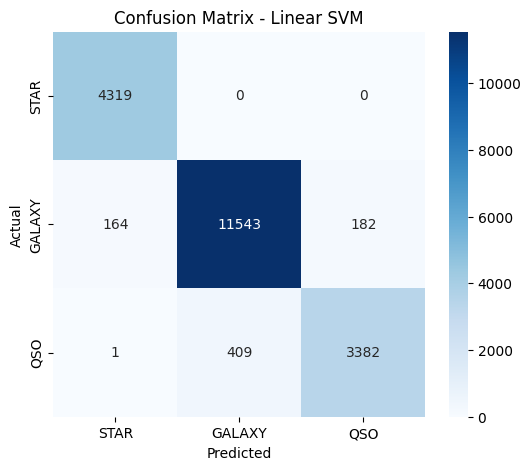

In [11]:
# Confusion Matrix for linear SVM
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_linear), annot=True, fmt='d', cmap='Blues', xticklabels=['STAR', 'GALAXY', 'QSO'], yticklabels=['STAR', 'GALAXY', 'QSO'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")
plt.show()

## SVM with Kernel

In [12]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

SVC()

In [13]:
y_pred = svm_model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9580
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      4319
           1       0.96      0.97      0.97     11889
           2       0.97      0.90      0.93      3792

    accuracy                           0.96     20000
   macro avg       0.96      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000



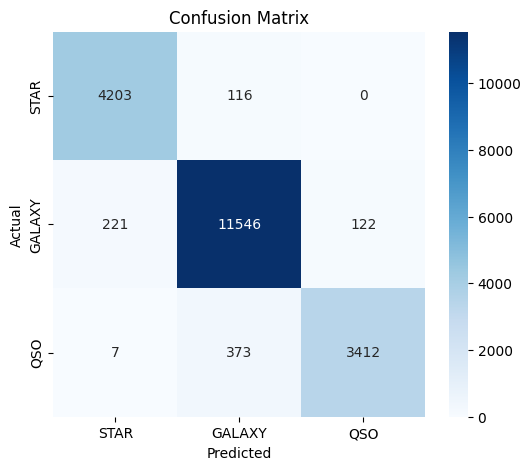

In [15]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['STAR', 'GALAXY', 'QSO'], yticklabels=['STAR', 'GALAXY', 'QSO'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Kernel SVM with PCA

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
# Reduce dataset size for visualization
X_train_pca_small = X_train_pca[:2000]  # Use only 2000 points
y_train_small = y_train[:2000]

In [ ]:

# Convert to NumPy array
y_train_small_np = y_train_small.to_numpy()


In [ ]:
# Ensure classes are within limits for visualization (e.g., select only 2 classes)
mask = (y_train_small_np == 0) | (y_train_small_np == 1)  # Example: Only STAR and GALAXY
X_train_pca_small_filtered = X_train_pca_small[mask]
y_train_small_filtered = y_train_small_np[mask]

In [ ]:

# Train a smaller SVM model
svm_pca_small = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_pca_small.fit(X_train_pca_small_filtered, y_train_small_filtered)

In [34]:
y_pred_pca = svm_pca_small.predict(X_train_pca_small_filtered)




In [35]:
print("Classification Report for PCA-Based SVM:")
print(classification_report(y_train_small_filtered, y_pred_pca, zero_division=0))


Classification Report for PCA-Based SVM:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       447
           1       0.72      1.00      0.84      1167

    accuracy                           0.72      1614
   macro avg       0.36      0.50      0.42      1614
weighted avg       0.52      0.72      0.61      1614



In [ ]:

# Plot decision boundary with fewer points
plt.figure(figsize=(8,6))
plot_decision_regions(X_train_pca_small_filtered, y_train_small_filtered, clf=svm_pca_small, legend=2)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("SVM Decision Boundary (PCA-Reduced Features for 2 Classes)")
plt.show()


Conclusion:
Model is bad at predicting stars, good at predicting galaxies (72%)

Future:
Increase accuracy of PCA SVM.